# CIFAR-10 CNN Hyperparameter Study

A systematic experiment log exploring how architectural choices — scheduler, filter width, depth, kernel size, and dropout — affect a small CNN trained on CIFAR-10 (50 k images, 10 classes, 32×32 px).

Each experiment batch fixes all variables except one, then measures val/loss and val/acc after 30 epochs.

## Setup

Imports, dataset download, and reproducibility helpers.

## Data Exploration

In [15]:
from torchvision.datasets import CIFAR10
from torchvision import transforms

transform = transforms.ToTensor()

train_set = CIFAR10(
    root =  'data',
    train = True,
    download = True,
    transform=transform
)
test_set = CIFAR10(
    root =  'data',
    train = False,
    download = True,
    transform=transform
)
CIFAR10_CLASSES = ['Airplane','Automobile','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']


In [16]:
print(next(iter(train_set))[0].shape, next(iter(train_set))[1])

torch.Size([3, 32, 32]) 6


50000


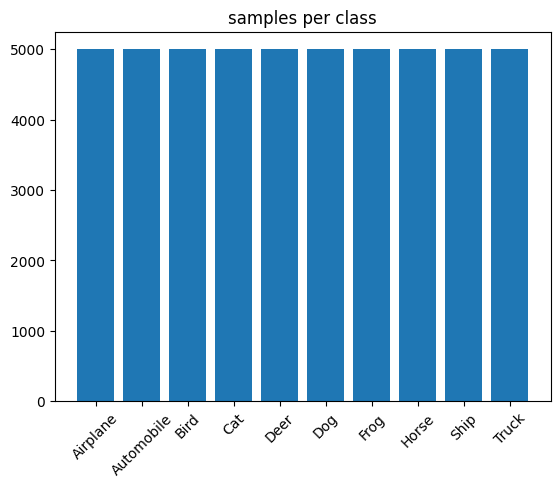

Min: 5000, Max: 5000


In [19]:
# How many data points?
print(len(train_set))
# are classes balanced?
import matplotlib.pyplot as plt

labels = [y for _, y in train_set]
from collections import Counter
counts = Counter(labels)

plt.bar([CIFAR10_CLASSES[i] for i in range(10)], 
        [counts[i] for i in range(10)])
plt.title("samples per class")
plt.xticks(rotation=45)
plt.show()

print(f"Min: {min(counts.values())}, Max: {max(counts.values())}")

50,000 images with 5000 images for each of the 10 classes

In [21]:
# Pixel stats per channel
# what does the actual data distribution look like?
# this is what your normalization constants are based on
import torch
imgs = torch.stack([x for x, _ in train_set])  # slow but thorough
# shape: [50000, 3, 32, 32]

for i, channel in enumerate(['R', 'G', 'B']):
    ch = imgs[:, i, :, :]
    print(f"{channel}: mean={ch.mean():.4f}  std={ch.std():.4f}  "
          f"min={ch.min():.4f}  max={ch.max():.4f}")


R: mean=0.4914  std=0.2470  min=0.0000  max=1.0000
G: mean=0.4822  std=0.2435  min=0.0000  max=1.0000
B: mean=0.4465  std=0.2616  min=0.0000  max=1.0000


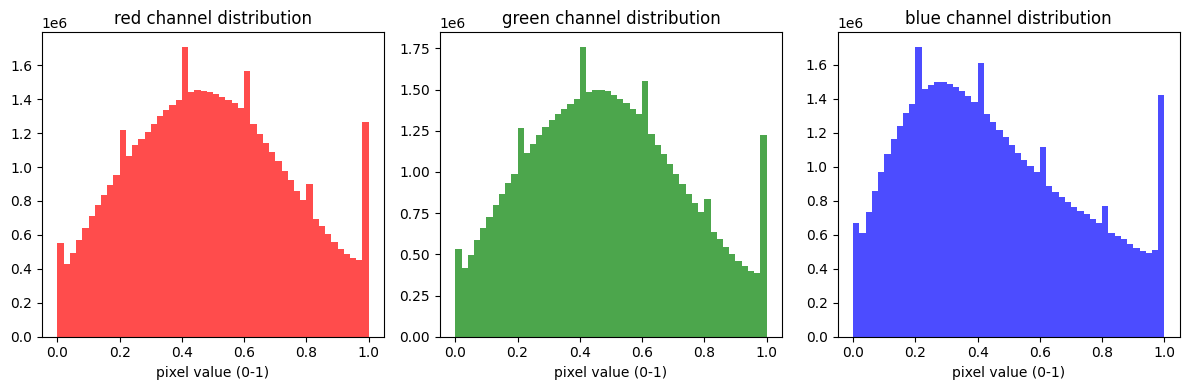

In [22]:
# are pixel values normally distributed? skewed? bimodal?
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = ['red', 'green', 'blue']

for i, (ax, color) in enumerate(zip(axes, colors)):
    channel_pixels = imgs[:, i].flatten().numpy()
    ax.hist(channel_pixels, bins=50, color=color, alpha=0.7)
    ax.set_title(f"{color} channel distribution")
    ax.set_xlabel("pixel value (0-1)")

plt.tight_layout()
plt.show()

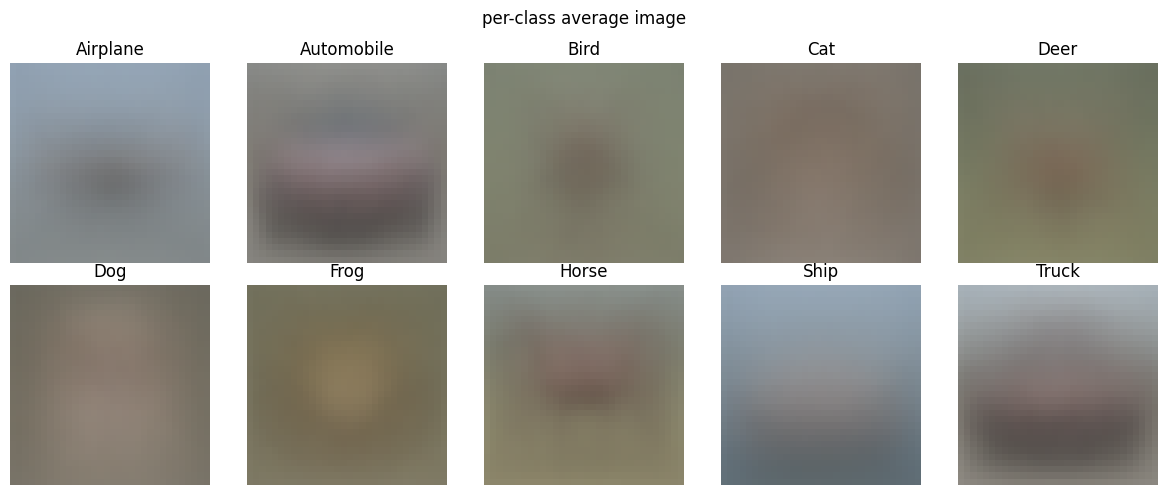

In [29]:
# vISUALIZE Average of each class
raw_set = torchvision.datasets.CIFAR10(root='./data', train=True, 
                                        download=False, transform=None)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for cls_idx, ax in enumerate(axes.flat):
    class_imgs = torch.stack([
        torchvision.transforms.ToTensor()(img)   # PIL → tensor, no normalize
        for img, label in raw_set if label == cls_idx
    ])
    mean_img = class_imgs.mean(dim=0).permute(1,2,0).numpy()
    ax.imshow(mean_img)
    ax.set_title(CIFAR10_CLASSES[cls_idx])
    ax.axis('off')

plt.suptitle("per-class average image")
plt.tight_layout()
plt.show()

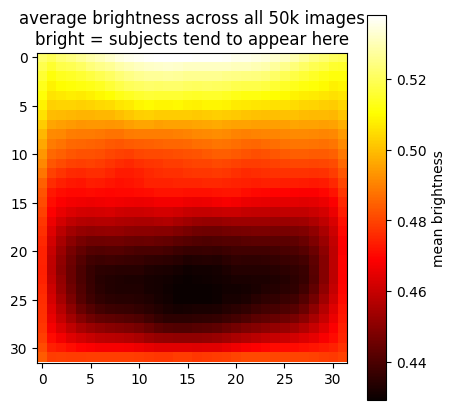

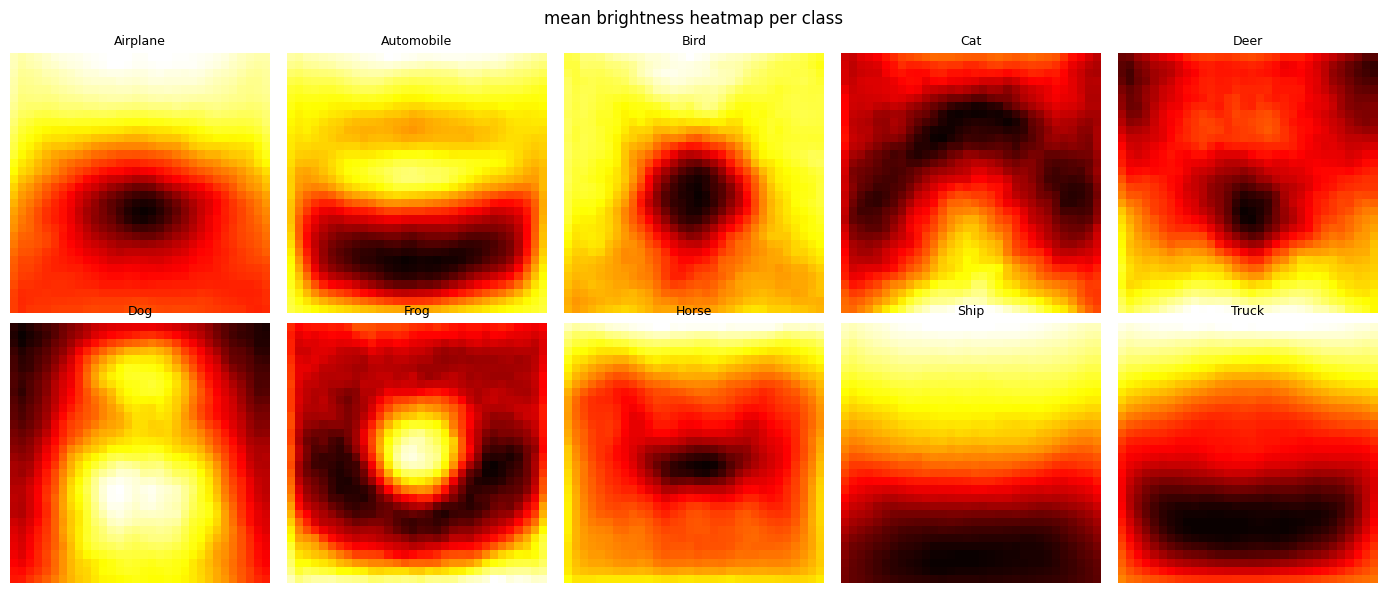

In [36]:
# Check if images are centered 
# average pixel intensity across all images — 
# bright spots = where subjects tend to be
import numpy as np
labels_arr = np.array([label for _, label in raw_set])

all_imgs = torch.stack([
    torchvision.transforms.ToTensor()(img) 
    for img, _ in raw_set
])  # [50000, 3, 32, 32]

mean_brightness = all_imgs.mean(dim=0).mean(dim=0).numpy()  # [32, 32]

plt.figure(figsize=(5, 5))
plt.imshow(mean_brightness, cmap='hot')
plt.colorbar(label='mean brightness')
plt.title("average brightness across all 50k images\n"
          "bright = subjects tend to appear here")
plt.show()

# per class version
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for cls_idx, ax in enumerate(axes.flat):
    mask = labels_arr == cls_idx
    cls_imgs = all_imgs[mask]
    brightness = cls_imgs.mean(dim=0).mean(dim=0).numpy()
    im = ax.imshow(brightness, cmap='hot')
    ax.set_title(CIFAR10_CLASSES[cls_idx], fontsize=9)
    ax.axis('off')

plt.suptitle("mean brightness heatmap per class")
plt.tight_layout()
plt.show()

In [ ]:
!uv add seaborn

Resolved 234 packages in 3.85s                                       
⠴ Preparing packages... (0/3)                                                   

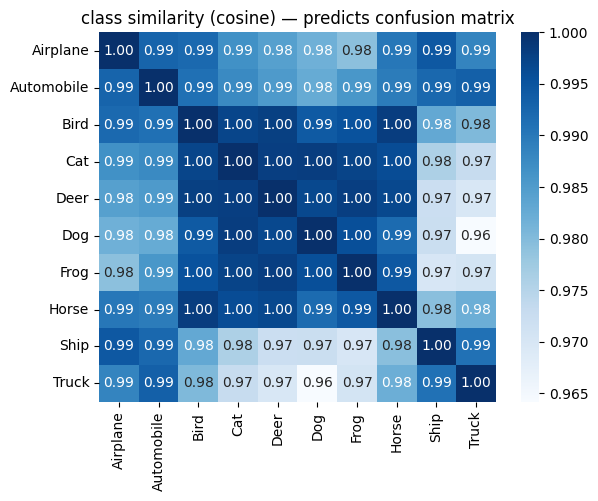

In [42]:
# which classes look most similar to each other?
# predicts where the model will struggle
import seaborn
class_means = []
for cls_idx in range(10):
    class_imgs = torch.stack([
        torchvision.transforms.ToTensor()(img)
        for img, label in raw_set if label == cls_idx
    ]).mean(dim=0).flatten()
    class_means.append(class_imgs)

class_means = torch.stack(class_means)  # [10, 3072]

# cosine similarity between class mean images
sim = torch.nn.functional.cosine_similarity(
    class_means.unsqueeze(1), 
    class_means.unsqueeze(0), 
    dim=2
)

import seaborn as sns
sns.heatmap(sim.numpy(), 
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            annot=True, fmt='.2f', cmap='Blues')
plt.title("class similarity (cosine) — predicts confusion matrix")
plt.show()

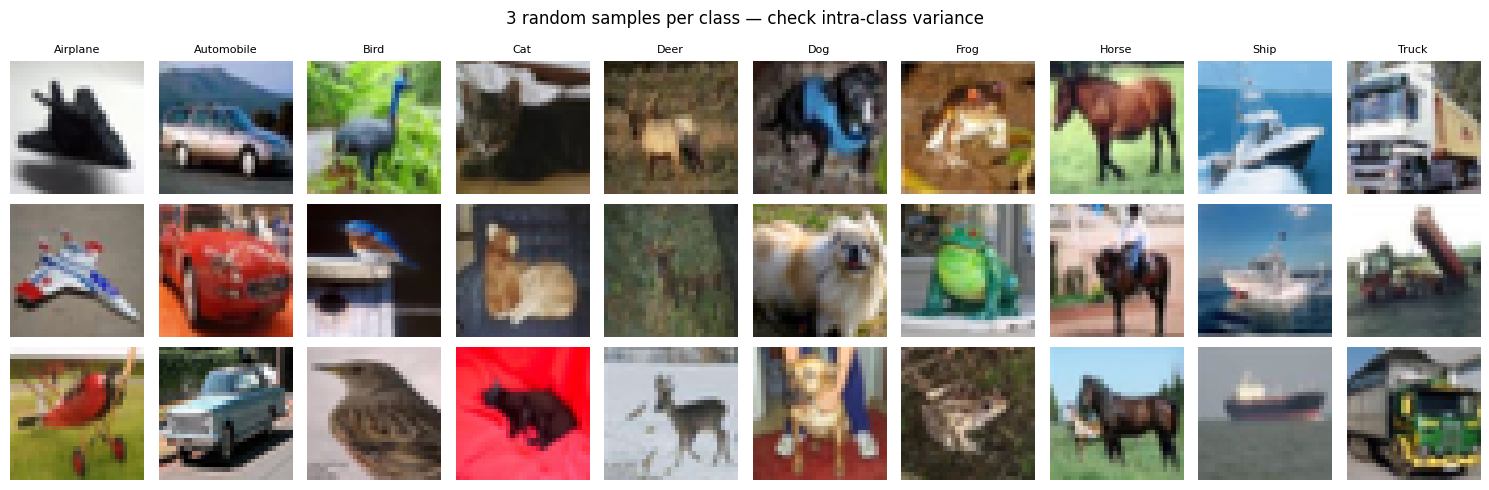

In [44]:
# are all examples of a class visually similar, or hugely varied?
# high variance = harder to learn

fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for cls_idx in range(10):
    class_imgs = [(img, label) for img, label in raw_set 
                  if label == cls_idx][:3]
    for row, (img, _) in enumerate(class_imgs):
        ax = axes[row, cls_idx]
        ax.imshow(img)
        if row == 0:
            ax.set_title(CIFAR10_CLASSES[cls_idx], fontsize=8)
        ax.axis('off')

plt.suptitle("3 random samples per class — check intra-class variance")
plt.tight_layout()
plt.show()

## Inferences
- No major class skew
- Will have to renormalize data around these values for the channel
R: mean=0.4914  std=0.2470  min=0.0000  max=1.0000
G: mean=0.4822  std=0.2435  min=0.0000  max=1.0000
B: mean=0.4465  std=0.2616  min=0.0000  max=1.0000
- A dog is least similar to a truck :)

In [46]:
from torchvision.datasets import CIFAR10
from torchvision import transforms

mean = [0.4914,0.4822 ,0.4465 ]
std = [0.2470,0.2435,0.2616 ]
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize(mean, std)]) 

train_set = CIFAR10(
    root =  'data',
    train = True,
    download = True,
    transform=transform
)
test_set = CIFAR10(
    root =  'data',
    train = False,
    download = True,
    transform=transform
)
CIFAR10_CLASSES = ['Airplane','Automobile','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']

In [51]:
train_loader = torch.utils.data.DataLoader(train_set, shuffle=True, batch_size=64)
test_loader = torch.utils.data.DataLoader(test_set, shuffle=True, batch_size=64)

In [52]:

import torch
import numpy as np
import random
import os

def set_seed(seed: int = 42) -> None:
    """
    Sets the random seed for reproducibility across multiple libraries and devices.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set as {seed}")

# Call the function at the beginning of your script
set_seed(42)

Random seed set as 42


In [59]:
# ESTIMATED Human baseline for this problem ~ 95%
CFG = dict(filters=[32,64,128], kernel=3, stride=1, depth=3, 
           pool="max", epochs=30, lr=3e-4, scheduler="none", img_dim = 32, dropout = 0.3,
              dataset       = "CIFAR10", batch_size = 64, optimizer = 'adam'
)
filters_experiments = [
    [16, 32, 64, 128],   # narrow
    [32, 64, 128, 256],  # baseline
    [64, 128, 256, 512], # wide
]
depth_experiments = [1, 2, 3, 4]  # blocks, baseline is 3

kernel_experiments = [3, 5, 7]    # 3 is baseline
scheduler_experiments = ["none", "step", "cosine", "plateau", "warmup_cosine"]

dropouts = [0.3,0.1,0.5]

In [72]:
from torch import nn
class CNN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.filters = cfg.filters
        self.kernel= cfg.kernel
        self.depth = cfg.depth
        #limit to depth
        self.filters = self.filters[:self.depth]
        in_channels = 3
        blocks = []
        #conv batch norm relu blocks
        for out_channels in self.filters:
            blocks.append(nn.Conv2d(in_channels,out_channels, kernel_size= self.kernel, padding=self.kernel//2, stride = 1))
            blocks.append(nn.BatchNorm2d(out_channels))
            blocks.append(nn.ReLU())
            blocks.append(nn.MaxPool2d(2))
            in_channels=out_channels

        self.features = nn.Sequential(*blocks)

        #classifier
        # H,W dimensions after depth number of pools -> img_dim/2^depth
        # depth will be self.filters[-1]
        
        # spatial size after len(filters) pools: 32 / 2^depth
        final_spatial = cfg.img_dim // (2 ** len(self.filters))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.filters[-1] * final_spatial * final_spatial, 256),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))
    
        

        
            

In [64]:
import wandb
run = wandb.init(
    project = "cifar10-cnn-study",
    name    = f"d{CFG['depth']}-f{CFG['filters'][-1]}-{CFG['optimizer']}",
    config  = CFG,
)
cfg = wandb.config

In [73]:
device = torch.accelerator.current_accelerator()
model   = CNN(cfg).to(device)
loss_fn = nn.CrossEntropyLoss()
optim   = (torch.optim.Adam if cfg.optimizer == "adam" 
           else torch.optim.SGD)(model.parameters(), lr=cfg.lr)
def get_scheduler(optim, cfg):
    if cfg.scheduler == "none":
        return None
    elif cfg.scheduler == "step":
        return torch.optim.lr_scheduler.StepLR(optim, step_size=10, gamma=0.1)
    elif cfg.scheduler == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=cfg.epochs)
    elif cfg.scheduler == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(optim, patience=3, verbose=True)
    elif cfg.scheduler == "warmup_cosine":
        def lr_lambda(epoch):
            warmup = 5
            if epoch < warmup:
                return (epoch + 1) / warmup
            progress = (epoch - warmup) / (cfg.epochs - warmup)
            return 0.5 * (1 + math.cos(math.pi * progress))
        return torch.optim.lr_scheduler.LambdaLR(optim, lr_lambda)

scheduler = get_scheduler(optim, cfg)

In [80]:
# check loss at init
x,y= next(iter(test_loader))
with torch.no_grad():
    loss = loss_fn( model(x.to(device)), y.to(device))
print(loss)
# 2. SANITY CHECK - overfit one batch — loss should reach < 0.01
x8, y8 = x[:8].to(device), y[:8].to(device)
model_test = CNN(cfg).to(device)
opt_test   = torch.optim.Adam(model_test.parameters(), lr=1e-3)
for step in range(200):
    l = loss_fn(model_test(x8), y8)
    opt_test.zero_grad(); l.backward(); opt_test.step()
print(f"overfit loss: {l.item():.6f}")  # expect < 0.01

tensor(2.3229, device='mps:0')
overfit loss: 0.000007


 Init loss Verify that your loss starts at the correct loss value. E.g. if you initialize your final layer correctly you should measure -log(1/n_classes) on a softmax at initialization. The same default values can be derived for L2 regression, Huber losses, etc.

In [82]:
def train_epoch(loader, model, optim, loss_fn):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        loss = loss_fn(model(x), y)
        optim.zero_grad()
        loss.backward()
        optim.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(loader, model, loss_fn):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            total_loss += loss_fn(preds, y).item()
            correct    += (preds.argmax(dim=1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total

In [83]:
for epoch in range(1, cfg.epochs + 1):
    train_loss            = train_epoch(train_loader, model, optim, loss_fn)
    val_loss, val_acc     = eval_epoch(test_loader,  model, loss_fn)

    run.log({
        "epoch":      epoch,
        "train/loss": train_loss,
        "val/loss":   val_loss,
        "val/acc":    val_acc,
        "lr":         optim.param_groups[0]['lr'],
    })
    print(f"Epoch {epoch:02d} | train={train_loss:.4f} "
          f"val={val_loss:.4f} acc={val_acc:.4f}")

run.finish()

Epoch 01 | train=1.2893 val=0.9963 acc=0.6475
Epoch 02 | train=0.9312 val=0.8624 acc=0.6976
Epoch 03 | train=0.7968 val=0.7830 acc=0.7223
Epoch 04 | train=0.7080 val=0.7088 acc=0.7553
Epoch 05 | train=0.6367 val=0.7422 acc=0.7408
Epoch 06 | train=0.5778 val=0.7116 acc=0.7554
Epoch 07 | train=0.5295 val=0.6954 acc=0.7624
Epoch 08 | train=0.4759 val=0.6770 acc=0.7701
Epoch 09 | train=0.4348 val=0.7114 acc=0.7610
Epoch 10 | train=0.3932 val=0.7097 acc=0.7650
Epoch 11 | train=0.3507 val=0.7084 acc=0.7693
Epoch 12 | train=0.3234 val=0.6639 acc=0.7829
Epoch 13 | train=0.2945 val=0.7260 acc=0.7727
Epoch 14 | train=0.2642 val=0.7371 acc=0.7771
Epoch 15 | train=0.2401 val=0.7886 acc=0.7714
Epoch 16 | train=0.2214 val=0.7330 acc=0.7816
Epoch 17 | train=0.1982 val=0.7946 acc=0.7783
Epoch 18 | train=0.1792 val=0.8045 acc=0.7807
Epoch 19 | train=0.1701 val=0.8138 acc=0.7814
Epoch 20 | train=0.1560 val=0.8534 acc=0.7802
Epoch 21 | train=0.1502 val=0.8159 acc=0.7835
Epoch 22 | train=0.1370 val=0.8866

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▄▅▆▆▆▇▇▇▇▇█▇▇▇███████▇█▇█▇▇██
val/loss,▇▅▃▂▃▂▂▁▂▂▂▁▂▂▃▂▄▄▄▅▄▅▇▆▇▆██▇▇
epoch,30
lr,0.0003
train/loss,0.09922
val/acc,0.7836
val/loss,0.96088


In [114]:
from types import SimpleNamespace

def make_experiments(base_cfg):
    exps = []
    base = base_cfg.copy()

    # 1. scheduler study — fix everything, vary scheduler
    for s in scheduler_experiments:
        exps.append({**base, 'scheduler': s,
                     'name': f"sched-{s}"})

    # 2. filter width study — fix scheduler to best scheduler 
    for f in filters_experiments:
        exps.append({**base, 'filters': f, 'scheduler': 'step',
                     'name': f"filters-{f[-1]}"})

    # 3. depth study
    for d in depth_experiments:
        exps.append({**base, 'depth': d, 'scheduler': 'step',
                     'name': f"depth-{d}"})

    # 4. kernel study
    for k in kernel_experiments:
        exps.append({**base, 'kernel': k, 'scheduler': 'step',
                     'name': f"kernel-{k}"})

    # 5. dropout study
    for dr in dropouts:
        exps.append({**base, 'dropout': dr, 'scheduler': 'step',
                     'name': f"dropout-{dr}"})

    return exps

experiments = make_experiments(CFG)
print(f"Total runs: {len(experiments)}")
for d in depth_experiments:
    cfg_test = SimpleNamespace(**{**CFG, 'depth': d, 'filters': [32,64,128,256]})
    m = CNN(cfg_test).to(device)
    x = torch.randn(2, 3, 32, 32).to(device)
    with torch.no_grad():
        out = m(x)
    print(f"depth={d} → output shape: {out.shape}")  # must be [2, 10]

Total runs: 18
depth=1 → output shape: torch.Size([2, 10])
depth=2 → output shape: torch.Size([2, 10])
depth=3 → output shape: torch.Size([2, 10])
depth=4 → output shape: torch.Size([2, 10])


In [91]:
import math
from types import SimpleNamespace

def get_scheduler(optim, cfg):
    if cfg.scheduler == "none":
        return None
    elif cfg.scheduler == "step":
        return torch.optim.lr_scheduler.StepLR(optim, step_size=10, gamma=0.1)
    elif cfg.scheduler == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=cfg.epochs)
    elif cfg.scheduler == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(optim, patience=3)
    elif cfg.scheduler == "warmup_cosine":
        def lr_lambda(epoch):
            warmup = 5
            if epoch < warmup:
                return (epoch + 1) / warmup
            progress = (epoch - warmup) / (cfg.epochs - warmup)
            return 0.5 * (1 + math.cos(math.pi * progress))
        return torch.optim.lr_scheduler.LambdaLR(optim, lr_lambda)

device = torch.accelerator.current_accelerator()

# only scheduler experiments
for exp in experiments[:len(scheduler_experiments)]:
    cfg = SimpleNamespace(**exp)   # dict → object so cfg.lr works

    run = wandb.init(              # ← must be inside loop
        project = "cifar10-cnn-study",
        name    = cfg.name,
        config  = exp,
        tags    = ["seed-fixed", "scheduler-study"],  

        reinit  = True,
    )
    set_seed(42) 
    model     = CNN(cfg).to(device)
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = (torch.optim.Adam if cfg.optimizer == "adam"
                 else torch.optim.SGD)(model.parameters(), lr=cfg.lr)
    scheduler = get_scheduler(optimizer, cfg)

    for epoch in range(1, cfg.epochs + 1):
        train_loss        = train_epoch(train_loader, model, optimizer, loss_fn)
        val_loss, val_acc = eval_epoch(test_loader,   model, loss_fn)

        if scheduler is not None:
            if cfg.scheduler == "plateau":
                scheduler.step(val_loss)
            else:
                scheduler.step()

        run.log({
            "epoch":      epoch,
            "train/loss": train_loss,
            "val/loss":   val_loss,
            "val/acc":    val_acc,
            "lr":         optimizer.param_groups[0]['lr'],
        })
        print(f"[{cfg.name}] epoch {epoch:02d} | "
              f"train={train_loss:.4f} val={val_loss:.4f} acc={val_acc:.4f}")

    run.finish()

Random seed set as 42
[sched-none] epoch 01 | train=1.2696 val=0.9922 acc=0.6482
[sched-none] epoch 02 | train=0.9275 val=0.8202 acc=0.7121
[sched-none] epoch 03 | train=0.8003 val=0.7943 acc=0.7217
[sched-none] epoch 04 | train=0.7138 val=0.7840 acc=0.7266
[sched-none] epoch 05 | train=0.6424 val=0.7664 acc=0.7349
[sched-none] epoch 06 | train=0.5798 val=0.7257 acc=0.7513
[sched-none] epoch 07 | train=0.5314 val=0.7053 acc=0.7494
[sched-none] epoch 08 | train=0.4852 val=0.6880 acc=0.7669
[sched-none] epoch 09 | train=0.4390 val=0.6545 acc=0.7785
[sched-none] epoch 10 | train=0.4022 val=0.7098 acc=0.7711
[sched-none] epoch 11 | train=0.3677 val=0.7123 acc=0.7704
[sched-none] epoch 12 | train=0.3352 val=0.7479 acc=0.7658
[sched-none] epoch 13 | train=0.3031 val=0.6998 acc=0.7741
[sched-none] epoch 14 | train=0.2763 val=0.7614 acc=0.7673
[sched-none] epoch 15 | train=0.2512 val=0.7100 acc=0.7881
[sched-none] epoch 16 | train=0.2289 val=0.7241 acc=0.7822
[sched-none] epoch 17 | train=0.21

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▄▅▅▅▆▆▇█▇▇▇▇▇██████▇█▇▇██▇█▇█
val/loss,▇▄▄▃▃▂▂▂▁▂▂▃▂▃▂▂▃▃▄▄▅▆▅▅▆▆█▆██
epoch,30
lr,0.0003
train/loss,0.09431
val/acc,0.7786
val/loss,1.02083


Random seed set as 42
[sched-step] epoch 01 | train=1.2696 val=0.9922 acc=0.6482
[sched-step] epoch 02 | train=0.9275 val=0.8202 acc=0.7121
[sched-step] epoch 03 | train=0.8003 val=0.7943 acc=0.7217
[sched-step] epoch 04 | train=0.7138 val=0.7840 acc=0.7266
[sched-step] epoch 05 | train=0.6424 val=0.7664 acc=0.7349
[sched-step] epoch 06 | train=0.5798 val=0.7257 acc=0.7513
[sched-step] epoch 07 | train=0.5314 val=0.7053 acc=0.7494
[sched-step] epoch 08 | train=0.4852 val=0.6880 acc=0.7669
[sched-step] epoch 09 | train=0.4390 val=0.6545 acc=0.7785
[sched-step] epoch 10 | train=0.4022 val=0.7098 acc=0.7711
[sched-step] epoch 11 | train=0.2797 val=0.6160 acc=0.7995
[sched-step] epoch 12 | train=0.2540 val=0.6184 acc=0.7998
[sched-step] epoch 13 | train=0.2426 val=0.6153 acc=0.8014
[sched-step] epoch 14 | train=0.2345 val=0.6168 acc=0.8028
[sched-step] epoch 15 | train=0.2243 val=0.6255 acc=0.8025
[sched-step] epoch 16 | train=0.2162 val=0.6306 acc=0.7998
[sched-step] epoch 17 | train=0.20

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▄▄▄▃▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▄▄▅▅▆▆▆▇▇████████████████████
val/loss,█▅▄▄▄▃▃▂▂▃▁▁▁▁▁▁▁▁▁▂▁▂▂▂▂▂▂▂▂▂
epoch,30
lr,0.0
train/loss,0.16651
val/acc,0.8022
val/loss,0.64825


Random seed set as 42
[sched-cosine] epoch 01 | train=1.2696 val=0.9922 acc=0.6482
[sched-cosine] epoch 02 | train=0.9274 val=0.8267 acc=0.7068
[sched-cosine] epoch 03 | train=0.7999 val=0.7813 acc=0.7260
[sched-cosine] epoch 04 | train=0.7114 val=0.7925 acc=0.7257
[sched-cosine] epoch 05 | train=0.6403 val=0.7760 acc=0.7317
[sched-cosine] epoch 06 | train=0.5753 val=0.7166 acc=0.7550
[sched-cosine] epoch 07 | train=0.5243 val=0.6943 acc=0.7565
[sched-cosine] epoch 08 | train=0.4744 val=0.6802 acc=0.7697
[sched-cosine] epoch 09 | train=0.4256 val=0.6363 acc=0.7823
[sched-cosine] epoch 10 | train=0.3849 val=0.7009 acc=0.7708
[sched-cosine] epoch 11 | train=0.3458 val=0.6694 acc=0.7817
[sched-cosine] epoch 12 | train=0.3078 val=0.7549 acc=0.7649
[sched-cosine] epoch 13 | train=0.2710 val=0.7030 acc=0.7764
[sched-cosine] epoch 14 | train=0.2397 val=0.7145 acc=0.7803
[sched-cosine] epoch 15 | train=0.2124 val=0.7040 acc=0.7906
[sched-cosine] epoch 16 | train=0.1878 val=0.7132 acc=0.7915
[s

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
train/loss,█▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▄▅▅▅▆▆▇▇▇▇▇▇▇████████████████
val/loss,█▅▄▄▄▃▂▂▁▂▂▃▂▃▂▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅
epoch,30
lr,0
train/loss,0.04864
val/acc,0.7944
val/loss,0.82844


Random seed set as 42
[sched-plateau] epoch 01 | train=1.2696 val=0.9922 acc=0.6482
[sched-plateau] epoch 02 | train=0.9275 val=0.8202 acc=0.7121
[sched-plateau] epoch 03 | train=0.8003 val=0.7943 acc=0.7217
[sched-plateau] epoch 04 | train=0.7138 val=0.7840 acc=0.7266
[sched-plateau] epoch 05 | train=0.6424 val=0.7664 acc=0.7349
[sched-plateau] epoch 06 | train=0.5798 val=0.7257 acc=0.7513
[sched-plateau] epoch 07 | train=0.5314 val=0.7053 acc=0.7494
[sched-plateau] epoch 08 | train=0.4852 val=0.6880 acc=0.7669
[sched-plateau] epoch 09 | train=0.4390 val=0.6545 acc=0.7785
[sched-plateau] epoch 10 | train=0.4022 val=0.7098 acc=0.7711
[sched-plateau] epoch 11 | train=0.3677 val=0.7123 acc=0.7704
[sched-plateau] epoch 12 | train=0.3352 val=0.7479 acc=0.7658
[sched-plateau] epoch 13 | train=0.3031 val=0.6998 acc=0.7741
[sched-plateau] epoch 14 | train=0.1901 val=0.6525 acc=0.8033
[sched-plateau] epoch 15 | train=0.1686 val=0.6614 acc=0.8028
[sched-plateau] epoch 16 | train=0.1601 val=0.66

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,████████████▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▅▄▄▃▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▄▄▅▅▆▆▆▇▇▇▆▇█████████████████
val/loss,█▄▄▄▃▃▂▂▁▂▂▃▂▁▁▁▁▂▁▁▁▂▂▂▂▂▂▂▂▁
epoch,30
lr,0.0
train/loss,0.12685
val/acc,0.801
val/loss,0.67664


Random seed set as 42
[sched-warmup_cosine] epoch 01 | train=1.5096 val=1.1901 acc=0.5814
[sched-warmup_cosine] epoch 02 | train=1.1166 val=0.9597 acc=0.6650
[sched-warmup_cosine] epoch 03 | train=0.9482 val=0.8991 acc=0.6831
[sched-warmup_cosine] epoch 04 | train=0.8455 val=0.8358 acc=0.7089
[sched-warmup_cosine] epoch 05 | train=0.7648 val=0.8093 acc=0.7195
[sched-warmup_cosine] epoch 06 | train=0.6774 val=0.7611 acc=0.7372
[sched-warmup_cosine] epoch 07 | train=0.6141 val=0.7550 acc=0.7309
[sched-warmup_cosine] epoch 08 | train=0.5505 val=0.7389 acc=0.7508
[sched-warmup_cosine] epoch 09 | train=0.4938 val=0.6661 acc=0.7704
[sched-warmup_cosine] epoch 10 | train=0.4445 val=0.6976 acc=0.7695
[sched-warmup_cosine] epoch 11 | train=0.3955 val=0.6794 acc=0.7713
[sched-warmup_cosine] epoch 12 | train=0.3490 val=0.7330 acc=0.7687
[sched-warmup_cosine] epoch 13 | train=0.3056 val=0.7128 acc=0.7696
[sched-warmup_cosine] epoch 14 | train=0.2642 val=0.7146 acc=0.7791
[sched-warmup_cosine] epoc

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▄▅▇██████▇▇▇▆▆▆▅▅▄▄▃▃▃▂▂▂▁▁▁▁▁
train/loss,█▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▄▄▅▆▆▆▇▇▇▇▇▇█████████████████
val/loss,█▅▄▃▃▂▂▂▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄
epoch,30
lr,0
train/loss,0.02779
val/acc,0.7933
val/loss,0.88387


## Experiment 1 — Scheduler: Findings
- Winner:     sched-step   (lowest val/loss ~0.64, stable after epoch 15)
- Runner-up:  sched-plateau (val/loss ~0.68, stable)
- Overfit:    sched-none, sched-warmup_cosine, sched-cosine
- Key finding: at 30 epochs, discrete LR drops outperform smooth decay.
             Cosine needs 60+ epochs to show its real advantage.
- Use for remaining experiments: sched-step

Now we use shed-step for further experiment batches

In [95]:
scheduler_experiments

['none', 'step', 'cosine', 'plateau', 'warmup_cosine']

In [105]:
for i, expt in enumerate(experiments[len(scheduler_experiments):]):
    expt['scheduler']= 'step'
    experiments[i+len(scheduler_experiments)] =expt

In [108]:
filter_width_experiments = experiments[len(scheduler_experiments):len(scheduler_experiments) + len(filters_experiments)]

In [111]:
for exp in filter_width_experiments:
    set_seed(42) 
    
    cfg = SimpleNamespace(**exp)   # dict → object so cfg.lr works

    run = wandb.init(              # ← must be inside loop
        project = "cifar10-cnn-study",
        name    = cfg.name,
        config  = exp,
        tags    = ["seed-fixed", "filter-width-study"],  

        reinit  = True,
    )
    model     = CNN(cfg).to(device)
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = (torch.optim.Adam if cfg.optimizer == "adam"
                 else torch.optim.SGD)(model.parameters(), lr=cfg.lr)
    scheduler = get_scheduler(optimizer, cfg)

    for epoch in range(1, cfg.epochs + 1):
        train_loss        = train_epoch(train_loader, model, optimizer, loss_fn)
        val_loss, val_acc = eval_epoch(test_loader,   model, loss_fn)

        if scheduler is not None:
            if cfg.scheduler == "plateau":
                scheduler.step(val_loss)
            else:
                scheduler.step()

        run.log({
            "epoch":      epoch,
            "train/loss": train_loss,
            "val/loss":   val_loss,
            "val/acc":    val_acc,
            "lr":         optimizer.param_groups[0]['lr'],
        })
        print(f"[{cfg.name}] epoch {epoch:02d} | "
              f"train={train_loss:.4f} val={val_loss:.4f} acc={val_acc:.4f}")

    run.finish()

KeyboardInterrupt: 

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


## Experiment 2 — Filter Width: Findings

- *Winner:*     filters-256  (best accuracy/compute tradeoff)
- *Finding:*    diminishing returns above 256 filters for CIFAR-10 at 32x32
            128→256 gives meaningful gains, 256→512 does not
- *Inference:*  model capacity is not the bottleneck above 256 filters —
            the bottleneck shifts to data augmentation and regularization
- For remaining experiments: filters=[32,64,128,256] depth=4

- filters-128:  ~0.76-0.77
- filters-256:  ~0.80-0.81
- filters-512:  ~0.82-0.83

- 128 → 256:  +4% val/acc
- 256 → 512:  +2% val/acc

In [119]:
depth_experiments_configs = experiments[len(scheduler_experiments)+len(filter_width_experiments):len(scheduler_experiments)+len(filter_width_experiments)+ len(depth_experiments) ]
for i, conf in enumerate(depth_experiments_configs):
    
    depth_experiments_configs[i]['filters'] = [32,64,128,256]

In [122]:
for exp in depth_experiments_configs:
    set_seed(42) 
    
    cfg = SimpleNamespace(**exp)   # dict → object so cfg.lr works

    run = wandb.init(              # ← must be inside loop
        project = "cifar10-cnn-study",
        name    = cfg.name,
        config  = exp,
        tags    = ["seed-fixed", "depth-study"],  

        reinit  = True,
    )
    model     = CNN(cfg).to(device)
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = (torch.optim.Adam if cfg.optimizer == "adam"
                 else torch.optim.SGD)(model.parameters(), lr=cfg.lr)
    scheduler = get_scheduler(optimizer, cfg)

    for epoch in range(1, cfg.epochs + 1):
        train_loss        = train_epoch(train_loader, model, optimizer, loss_fn)
        val_loss, val_acc = eval_epoch(test_loader,   model, loss_fn)

        if scheduler is not None:
            if cfg.scheduler == "plateau":
                scheduler.step(val_loss)
            else:
                scheduler.step()

        run.log({
            "epoch":      epoch,
            "train/loss": train_loss,
            "val/loss":   val_loss,
            "val/acc":    val_acc,
            "lr":         optimizer.param_groups[0]['lr'],
        })
        print(f"[{cfg.name}] epoch {epoch:02d} | "
              f"train={train_loss:.4f} val={val_loss:.4f} acc={val_acc:.4f}")

    run.finish()

Random seed set as 42


[depth-1] epoch 01 | train=1.5086 val=1.2293 acc=0.5590
[depth-1] epoch 02 | train=1.2205 val=1.1195 acc=0.5974
[depth-1] epoch 03 | train=1.0950 val=1.0309 acc=0.6378
[depth-1] epoch 04 | train=1.0057 val=1.0039 acc=0.6480
[depth-1] epoch 05 | train=0.9334 val=0.9745 acc=0.6607
[depth-1] epoch 06 | train=0.8703 val=0.9615 acc=0.6636
[depth-1] epoch 07 | train=0.8242 val=0.9616 acc=0.6666
[depth-1] epoch 08 | train=0.7728 val=0.9359 acc=0.6748
[depth-1] epoch 09 | train=0.7344 val=0.9315 acc=0.6808
[depth-1] epoch 10 | train=0.6919 val=0.9328 acc=0.6795
[depth-1] epoch 11 | train=0.5658 val=0.9107 acc=0.6961
[depth-1] epoch 12 | train=0.5474 val=0.9085 acc=0.6947
[depth-1] epoch 13 | train=0.5322 val=0.9131 acc=0.6983
[depth-1] epoch 14 | train=0.5271 val=0.9087 acc=0.6964
[depth-1] epoch 15 | train=0.5154 val=0.9151 acc=0.6986
[depth-1] epoch 16 | train=0.5077 val=0.9174 acc=0.6973
[depth-1] epoch 17 | train=0.4989 val=0.9216 acc=0.7006
[depth-1] epoch 18 | train=0.4958 val=0.9243 acc

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▅▄▄▃▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▃▅▅▆▆▆▇▇▇████████████████████
val/loss,█▆▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
lr,0.0
train/loss,0.45779
val/acc,0.7014
val/loss,0.92455


Random seed set as 42


[depth-2] epoch 01 | train=1.3392 val=1.0842 acc=0.6047
[depth-2] epoch 02 | train=1.0073 val=0.9215 acc=0.6788
[depth-2] epoch 03 | train=0.8898 val=0.9143 acc=0.6751
[depth-2] epoch 04 | train=0.8191 val=0.8161 acc=0.7142
[depth-2] epoch 05 | train=0.7574 val=0.8345 acc=0.7090
[depth-2] epoch 06 | train=0.7044 val=0.8051 acc=0.7215
[depth-2] epoch 07 | train=0.6547 val=0.7627 acc=0.7343
[depth-2] epoch 08 | train=0.6117 val=0.7323 acc=0.7506
[depth-2] epoch 09 | train=0.5743 val=0.7412 acc=0.7455
[depth-2] epoch 10 | train=0.5358 val=0.7325 acc=0.7516
[depth-2] epoch 11 | train=0.4257 val=0.6753 acc=0.7716
[depth-2] epoch 12 | train=0.4013 val=0.6739 acc=0.7717
[depth-2] epoch 13 | train=0.3947 val=0.6790 acc=0.7702
[depth-2] epoch 14 | train=0.3820 val=0.6753 acc=0.7735
[depth-2] epoch 15 | train=0.3754 val=0.6716 acc=0.7727
[depth-2] epoch 16 | train=0.3658 val=0.6738 acc=0.7742
[depth-2] epoch 17 | train=0.3626 val=0.6751 acc=0.7745
[depth-2] epoch 18 | train=0.3538 val=0.6777 acc

...

[depth-3] epoch 01 | train=1.2696 val=0.9922 acc=0.6482
[depth-3] epoch 02 | train=0.9275 val=0.8202 acc=0.7121
[depth-3] epoch 03 | train=0.8003 val=0.7943 acc=0.7217
[depth-3] epoch 04 | train=0.7138 val=0.7840 acc=0.7266
[depth-3] epoch 05 | train=0.6424 val=0.7664 acc=0.7349
[depth-3] epoch 06 | train=0.5798 val=0.7257 acc=0.7513
[depth-3] epoch 07 | train=0.5314 val=0.7053 acc=0.7494
[depth-3] epoch 08 | train=0.4852 val=0.6880 acc=0.7669
[depth-3] epoch 09 | train=0.4390 val=0.6545 acc=0.7785
[depth-3] epoch 10 | train=0.4022 val=0.7098 acc=0.7711
[depth-3] epoch 11 | train=0.2797 val=0.6160 acc=0.7995
[depth-3] epoch 12 | train=0.2540 val=0.6184 acc=0.7998
[depth-3] epoch 13 | train=0.2426 val=0.6153 acc=0.8014
[depth-3] epoch 14 | train=0.2345 val=0.6168 acc=0.8028
[depth-3] epoch 15 | train=0.2243 val=0.6255 acc=0.8025
[depth-3] epoch 16 | train=0.2162 val=0.6306 acc=0.7998
[depth-3] epoch 17 | train=0.2081 val=0.6344 acc=0.8001
[depth-3] epoch 18 | train=0.2000 val=0.6414 acc

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▄▄▄▃▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▄▄▅▅▆▆▆▇▇████████████████████
val/loss,█▅▄▄▄▃▃▂▂▃▁▁▁▁▁▁▁▁▁▂▁▂▂▂▂▂▂▂▂▂
epoch,30
lr,0.0
train/loss,0.16651
val/acc,0.8022
val/loss,0.64825


Random seed set as 42


[depth-4] epoch 01 | train=1.2239 val=1.0083 acc=0.6405
[depth-4] epoch 02 | train=0.8408 val=0.8164 acc=0.7082
[depth-4] epoch 03 | train=0.6864 val=0.7834 acc=0.7325
[depth-4] epoch 04 | train=0.5717 val=0.6728 acc=0.7688
[depth-4] epoch 05 | train=0.4829 val=0.6406 acc=0.7829
[depth-4] epoch 06 | train=0.4117 val=0.6953 acc=0.7733
[depth-4] epoch 07 | train=0.3372 val=0.6579 acc=0.7882
[depth-4] epoch 08 | train=0.2802 val=0.7615 acc=0.7741
[depth-4] epoch 09 | train=0.2356 val=0.8123 acc=0.7710
[depth-4] epoch 10 | train=0.1904 val=0.7787 acc=0.7824
[depth-4] epoch 11 | train=0.0789 val=0.7295 acc=0.8111
[depth-4] epoch 12 | train=0.0525 val=0.7548 acc=0.8081
[depth-4] epoch 13 | train=0.0433 val=0.7827 acc=0.8081
[depth-4] epoch 14 | train=0.0369 val=0.7862 acc=0.8089
[depth-4] epoch 15 | train=0.0310 val=0.8128 acc=0.8081
[depth-4] epoch 16 | train=0.0262 val=0.8295 acc=0.8059
[depth-4] epoch 17 | train=0.0233 val=0.8332 acc=0.8062
[depth-4] epoch 18 | train=0.0203 val=0.8576 acc

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▄▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▄▅▆▇▆▇▆▆▇████████████████████
val/loss,█▄▄▂▁▂▁▃▄▄▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆
epoch,30
lr,0.0
train/loss,0.00866
val/acc,0.8066
val/loss,0.91375


## Experiment 3 — Depth: Findings

- Winner:     depth-3  (best val/loss, stable, ~0.81 val/acc)
- Finding:    depth-4 overfits — resolution-depth mismatch
            32×32 images can't support 4 pooling operations cleanly
            2×2 final spatial = too much compression
- Underfits:  depth-1 (0.70), depth-2 (0.78) — insufficient capacity
- Sweet spot: depth-3, 4×4 final spatial, matches image resolution
- To be Used for remaining experiments: depth=3, filters=[32,64,128,256]

In [123]:
optimal_filters = [64, 128, 256]   
optimal_depth   = 3
optimal_sched = 'step'


In [129]:
# So far best baseline
baseline = experiments[1]
baseline['scheduler'] = optimal_sched
baseline['filters'] = optimal_filters
baseline['depth'] = optimal_depth
baseline

{'filters': [64, 128, 256],
 'kernel': 3,
 'stride': 1,
 'depth': 3,
 'pool': 'max',
 'epochs': 30,
 'lr': 0.0003,
 'scheduler': 'step',
 'img_dim': 32,
 'dropout': 0.3,
 'dataset': 'CIFAR10',
 'batch_size': 64,
 'optimizer': 'adam',
 'name': 'sched-step'}

In [130]:
exp = baseline
# run the consolidated baseline
set_seed(42) 

cfg = SimpleNamespace(**exp)   # dict → object so cfg.lr works

run = wandb.init(              # ← must be inside loop
    project = "cifar10-cnn-study",
    name    = cfg.name,
    config  = exp,
    tags    = ["seed-fixed", "baseline-step-256-d3-study"],  

    reinit  = True,
)
model     = CNN(cfg).to(device)
loss_fn   = nn.CrossEntropyLoss()
optimizer = (torch.optim.Adam if cfg.optimizer == "adam"
             else torch.optim.SGD)(model.parameters(), lr=cfg.lr)
scheduler = get_scheduler(optimizer, cfg)

for epoch in range(1, cfg.epochs + 1):
    train_loss        = train_epoch(train_loader, model, optimizer, loss_fn)
    val_loss, val_acc = eval_epoch(test_loader,   model, loss_fn)

    if scheduler is not None:
        if cfg.scheduler == "plateau":
            scheduler.step(val_loss)
        else:
            scheduler.step()

    run.log({
        "epoch":      epoch,
        "train/loss": train_loss,
        "val/loss":   val_loss,
        "val/acc":    val_acc,
        "lr":         optimizer.param_groups[0]['lr'],
    })
    print(f"[{cfg.name}] epoch {epoch:02d} | "
          f"train={train_loss:.4f} val={val_loss:.4f} acc={val_acc:.4f}")

run.finish()

Random seed set as 42


[sched-step] epoch 01 | train=1.2227 val=0.9422 acc=0.6665
[sched-step] epoch 02 | train=0.8659 val=0.9079 acc=0.6816
[sched-step] epoch 03 | train=0.7385 val=0.7321 acc=0.7491
[sched-step] epoch 04 | train=0.6435 val=0.7390 acc=0.7458
[sched-step] epoch 05 | train=0.5771 val=0.6345 acc=0.7786
[sched-step] epoch 06 | train=0.5099 val=0.6320 acc=0.7795
[sched-step] epoch 07 | train=0.4517 val=0.6740 acc=0.7758
[sched-step] epoch 08 | train=0.3965 val=0.6629 acc=0.7804
[sched-step] epoch 09 | train=0.3503 val=0.6156 acc=0.7957
[sched-step] epoch 10 | train=0.3084 val=0.6839 acc=0.7871
[sched-step] epoch 11 | train=0.1766 val=0.5598 acc=0.8240
[sched-step] epoch 12 | train=0.1462 val=0.5623 acc=0.8289
[sched-step] epoch 13 | train=0.1319 val=0.5658 acc=0.8260
[sched-step] epoch 14 | train=0.1212 val=0.5631 acc=0.8251
[sched-step] epoch 15 | train=0.1133 val=0.5725 acc=0.8256
[sched-step] epoch 16 | train=0.1032 val=0.5897 acc=0.8226
[sched-step] epoch 17 | train=0.0961 val=0.5875 acc=0.82

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▅▄▄▃▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▂▅▄▆▆▆▆▇▆████████████████████
val/loss,█▇▄▄▂▂▃▃▂▃▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
epoch,30
lr,0.0
train/loss,0.0591
val/acc,0.8286
val/loss,0.61769


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6243074..1.5669287].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7548175..2.0591094].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.115826].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5608003..1.4399143].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8997625..2.0298588].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5776623..1.5034215].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6719378

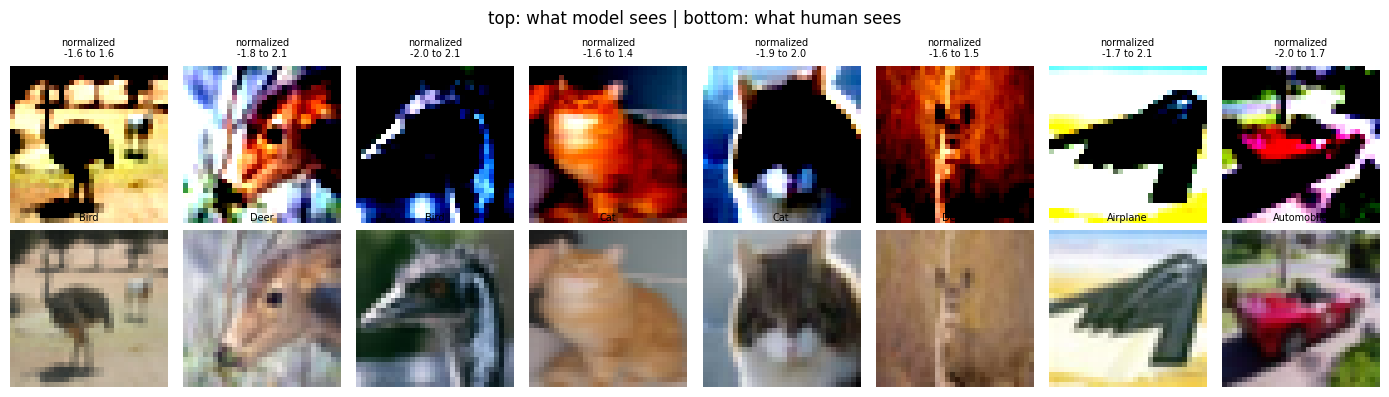

In [131]:
def show_preprocessed(loader, n=8):
    x, y = next(iter(loader))
    
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
    
    fig, axes = plt.subplots(2, n, figsize=(14, 4))
    for i in range(n):
        # top row: what model sees (normalized tensor)
        raw = x[i]
        axes[0,i].imshow(raw.permute(1,2,0).numpy(), 
                         vmin=-2, vmax=2, cmap='RdBu_r')
        axes[0,i].set_title(f"normalized\n{raw.min():.1f} to {raw.max():.1f}", 
                            fontsize=7)
        axes[0,i].axis('off')
        
        # bottom row: human-viewable version
        img = (raw * std + mean).clamp(0,1).permute(1,2,0).numpy()
        axes[1,i].imshow(img)
        axes[1,i].set_title(CIFAR10_CLASSES[y[i]], fontsize=7)
        axes[1,i].axis('off')
    
    plt.suptitle("top: what model sees | bottom: what human sees")
    plt.tight_layout()
    plt.show()

show_preprocessed(train_loader)

In [133]:
# storage for activations
activations = {}

def make_hook(name):
    def hook(module, input, output):
        activations[name] = output.detach()
    return hook

# register hooks on each conv layer
hooks = []
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        hooks.append(module.register_forward_hook(make_hook(name)))

# run one forward pass
model.eval()
x, y = next(iter(test_loader))
x_single = x[0:1].to(device)   # one image

with torch.no_grad():
    _ = model(x_single)

# remove hooks after use — important, they persist otherwise
for h in hooks:
    h.remove()

print("Captured activations:")
for name, act in activations.items():
    print(f"  {name}: {act.shape}")

Captured activations:
  features.0: torch.Size([1, 64, 32, 32])
  features.4: torch.Size([1, 128, 16, 16])
  features.8: torch.Size([1, 256, 8, 8])


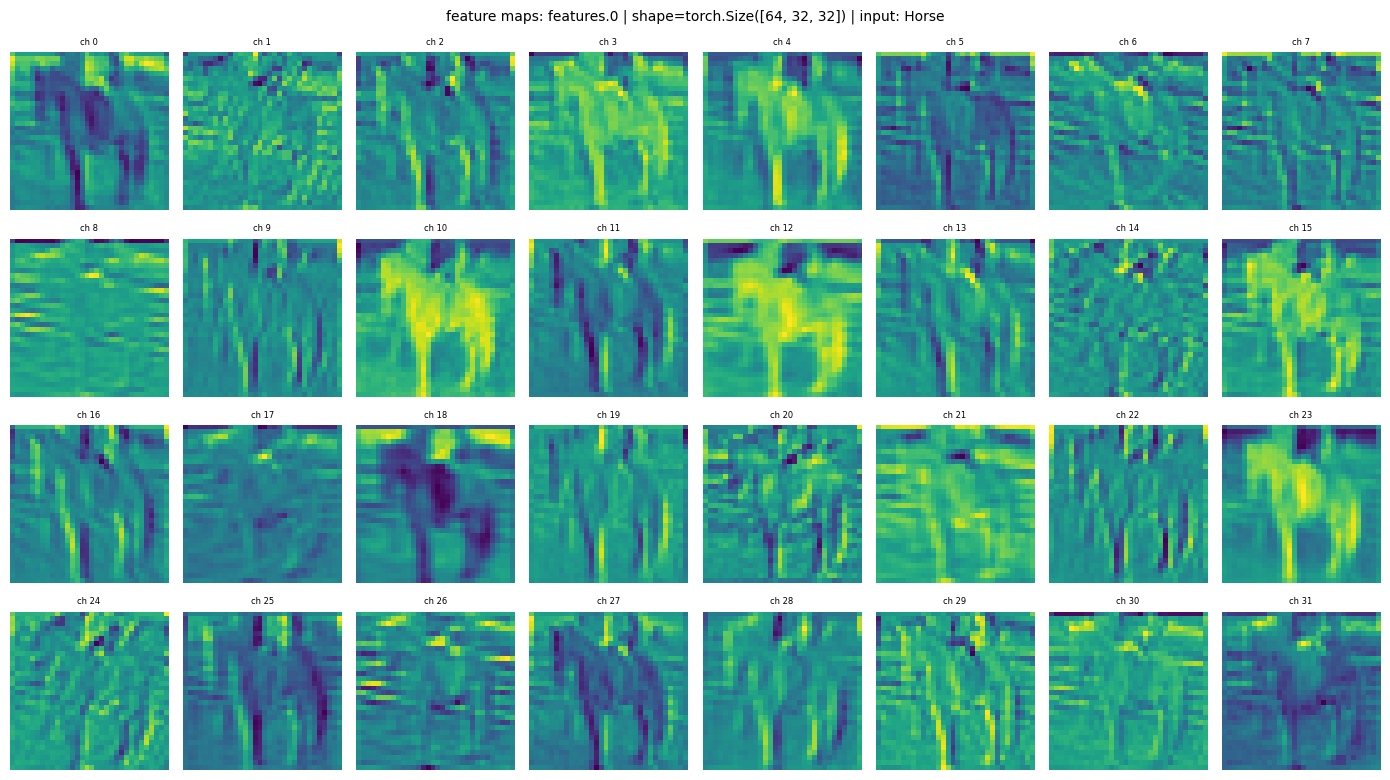

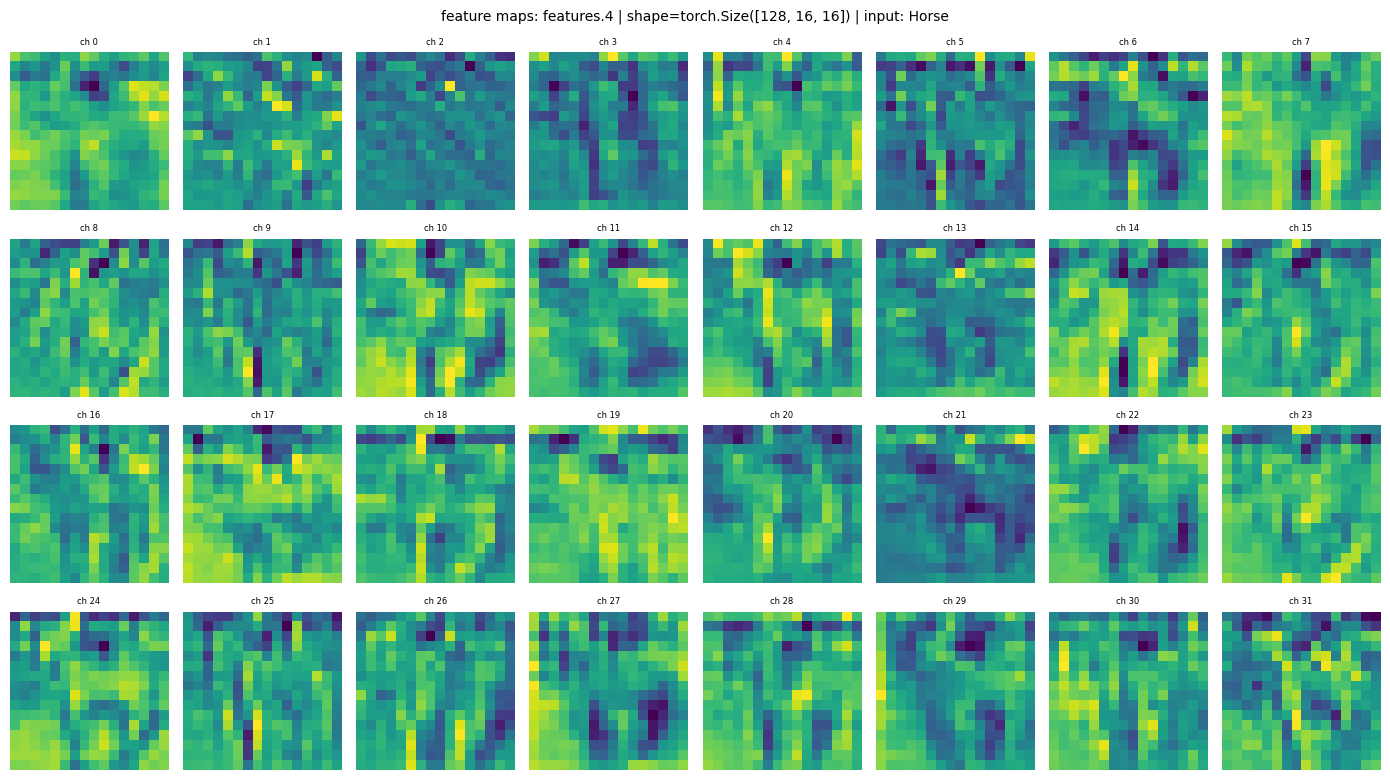

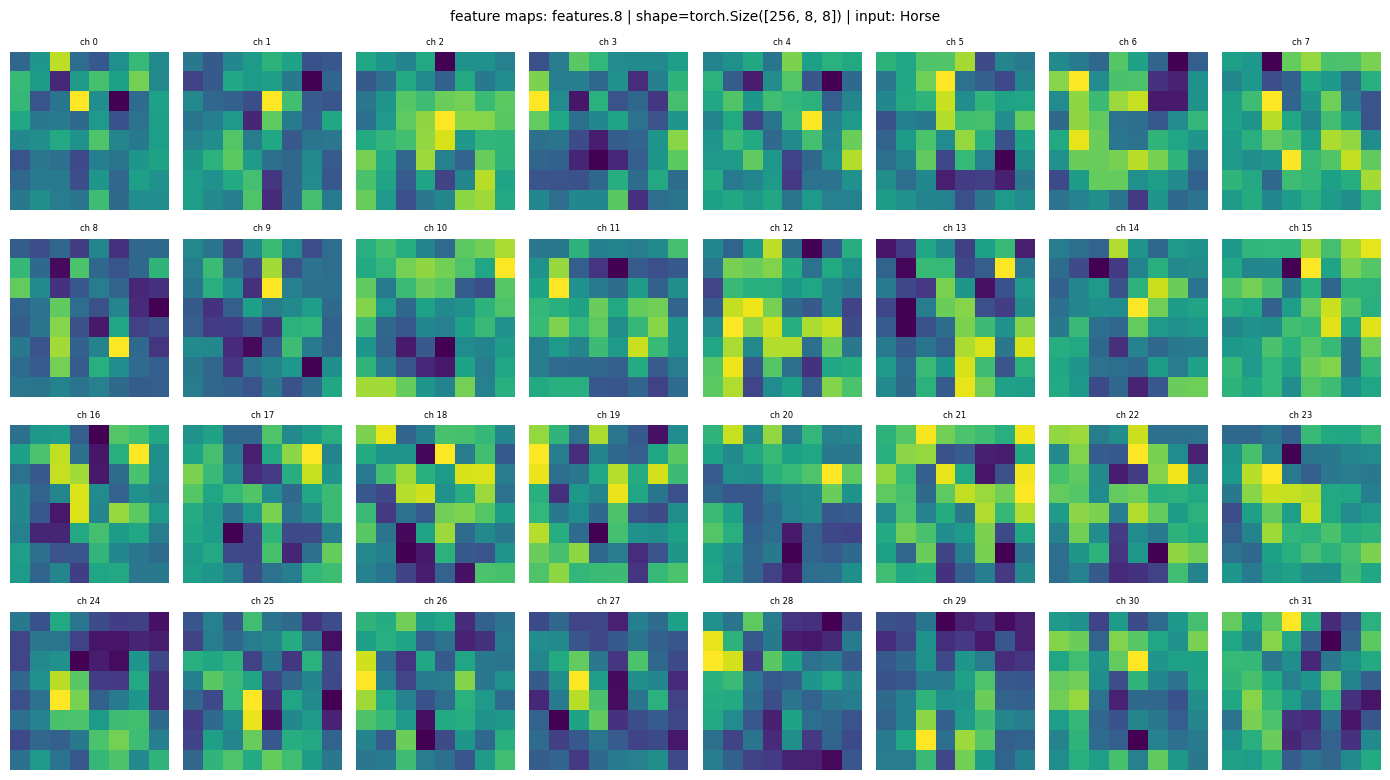

In [134]:
def show_feature_maps(activations, layer_name, max_channels=32):
    act = activations[layer_name].squeeze(0).cpu()  # [C, H, W]
    n   = min(max_channels, act.shape[0])
    
    cols = 8
    rows = n // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows*2))
    
    for i, ax in enumerate(axes.flat[:n]):
        fm = act[i].numpy()
        # normalize each feature map independently for visibility
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        ax.imshow(fm, cmap='viridis')
        ax.set_title(f"ch {i}", fontsize=6)
        ax.axis('off')
    
    # show original image alongside
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
    img  = (x_single.cpu().squeeze() * std + mean).clamp(0,1).permute(1,2,0)
    
    plt.suptitle(f"feature maps: {layer_name} | "
                 f"shape={act.shape} | "
                 f"input: {CIFAR10_CLASSES[y[0]]}", 
                 fontsize=10)
    plt.tight_layout()
    plt.show()

# visualize each conv layer
for name in activations:
    show_feature_maps(activations, name)

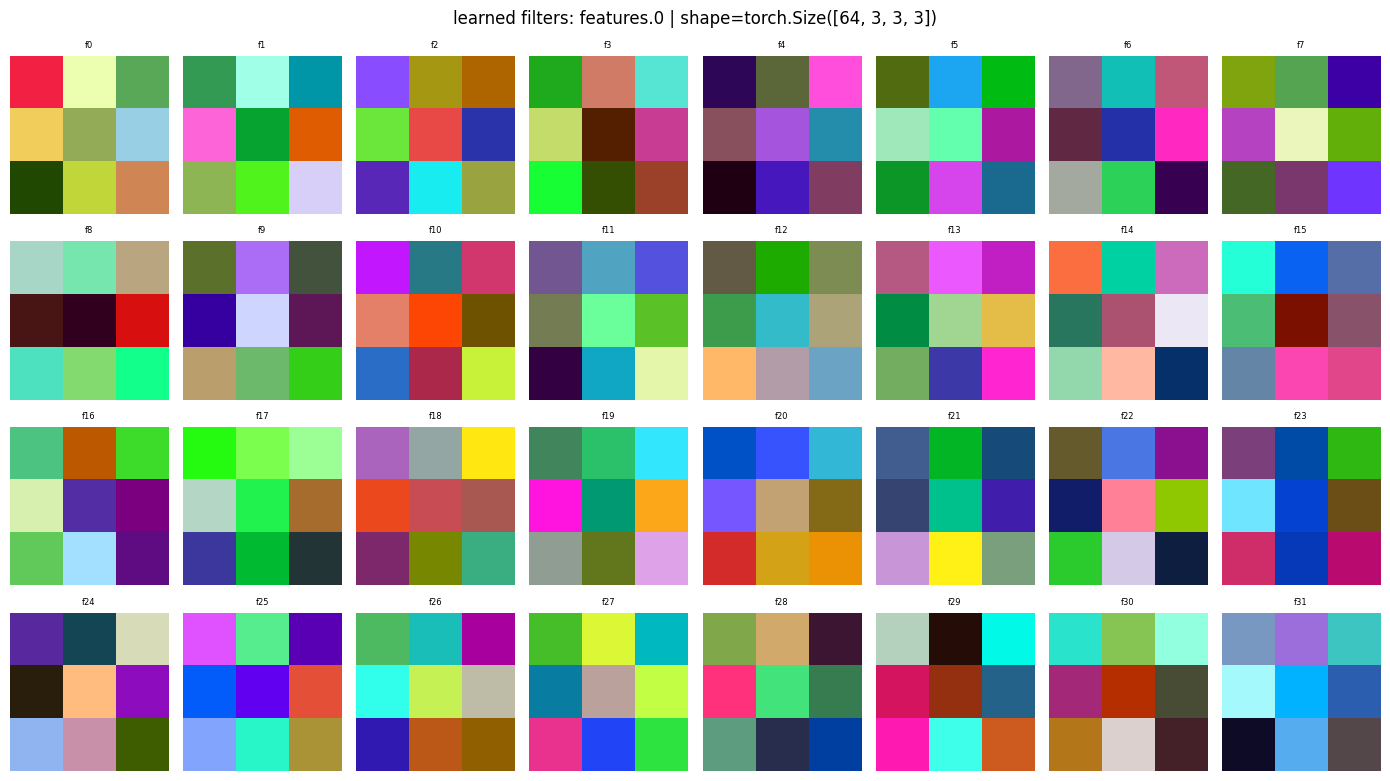

In [135]:
def show_conv_filters(model, max_filters=32):
    # get all conv layers
    conv_layers = [(name, m) for name, m in model.named_modules() 
                   if isinstance(m, nn.Conv2d)]
    
    # first layer only — these are directly interpretable
    name, first_conv = conv_layers[0]
    weights = first_conv.weight.data.cpu()  # [out_ch, in_ch, kH, kW]
    
    n    = min(max_filters, weights.shape[0])
    cols = 8
    rows = n // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows*2))
    for i, ax in enumerate(axes.flat[:n]):
        f = weights[i]                    # [3, kH, kW]
        f = (f - f.min()) / (f.max() - f.min() + 1e-8)
        f = f.permute(1,2,0).numpy()     # [kH, kW, 3] for RGB display
        ax.imshow(f)
        ax.set_title(f"f{i}", fontsize=6)
        ax.axis('off')
    
    plt.suptitle(f"learned filters: {name} | "
                 f"shape={weights.shape}")
    plt.tight_layout()
    plt.show()

show_conv_filters(model)

## Model Interpretability
- The below activation heatmap shows where the model pays attention in the image to classify the image ?

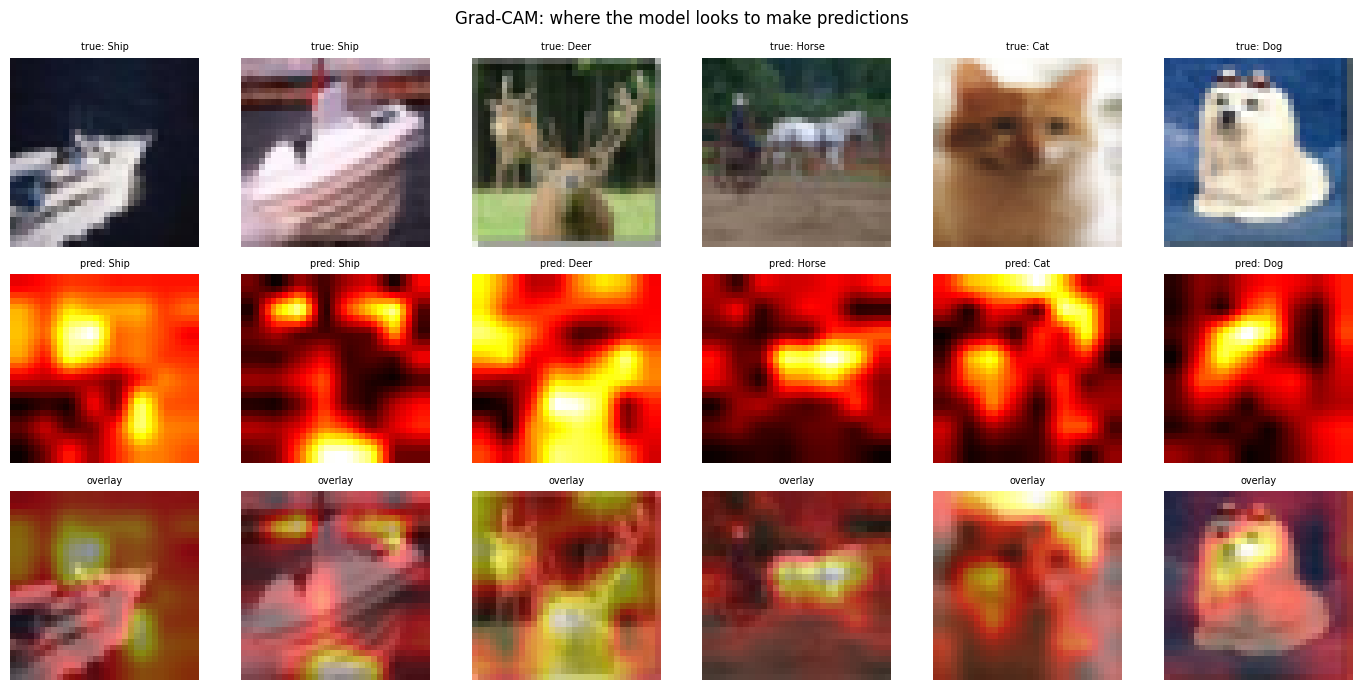

In [143]:
import cv2
def grad_cam(model, x_single, target_class, target_layer):
    model.eval()
    
    gradients = {}
    activations_gc = {}
    
    def save_gradient(name):
        def hook(module, grad_input, grad_output):
            gradients[name] = grad_output[0]
        return hook
    
    def save_activation(name):
        def hook(module, input, output):
            activations_gc[name] = output
        return hook
    
    # find target layer
    for name, module in model.named_modules():
        if name == target_layer:
            module.register_forward_hook(save_activation(name))
            module.register_backward_hook(save_gradient(name))
    
    # forward
    x_single.requires_grad_(True)
    output = model(x_single)
    
    # backward on target class
    model.zero_grad()
    output[0, target_class].backward()
    
    # compute grad-cam
    grads   = gradients[target_layer]          # [1, C, H, W]
    acts    = activations_gc[target_layer]     # [1, C, H, W]
    weights = grads.mean(dim=[2,3], keepdim=True)  # global avg pool
    cam     = (weights * acts).sum(dim=1).squeeze()
    cam = cam.abs()
    cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam     = cam.cpu().detach().numpy()
    
    return cam

# find last conv layer name
last_conv_name = [(name, m) for name, m in model.named_modules() 
                  if isinstance(m, nn.Conv2d)][-1][0]

# visualize for a few test images
fig, axes = plt.subplots(3, 6, figsize=(14, 7))
x_batch, y_batch = next(iter(test_loader))

for i in range(6):
    x_single = x_batch[i:i+1].to(device)
    true_cls  = y_batch[i].item()
    
    # get prediction
    with torch.no_grad():
        pred_cls = model(x_single).argmax(dim=1).item()
    
    # get grad-cam
    cam = grad_cam(model, x_single, pred_cls, last_conv_name)
    
    # original image
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
    img = (x_single.detach().cpu().squeeze() * std + mean).clamp(0,1).permute(1,2,0).numpy()
    
    # resize cam to image size
    import cv2
    cam_resized = cv2.resize(cam, (32, 32))
    
    # row 0: original
    axes[0,i].imshow(img)
    axes[0,i].set_title(f"true: {CIFAR10_CLASSES[true_cls]}", fontsize=7)
    axes[0,i].axis('off')
    
    # row 1: grad-cam heatmap
    axes[1,i].imshow(cam_resized, cmap='hot')
    axes[1,i].set_title(f"pred: {CIFAR10_CLASSES[pred_cls]}", fontsize=7)
    axes[1,i].axis('off')
    
    # row 2: overlay
    axes[2,i].imshow(img)
    axes[2,i].imshow(cam_resized, cmap='hot', alpha=0.5)
    axes[2,i].set_title("overlay", fontsize=7)
    axes[2,i].axis('off')

plt.suptitle("Grad-CAM: where the model looks to make predictions")
plt.tight_layout()
plt.show()


In [155]:
# Kernel experiments
kernel_expt = filter(lambda e: 'kernel' in e['name'], experiments)

In [156]:
kernel_expt= list(kernel_expt)
for i, expt in enumerate(kernel_expt):
    kernel_expt[i]['scheduler'] = optimal_sched
    kernel_expt[i]['filters'] = optimal_filters
    kernel_expt[i]['depth'] = optimal_depth

In [158]:
for exp in kernel_expt:
    set_seed(42) 
    
    cfg = SimpleNamespace(**exp)   # dict → object so cfg.lr works

    run = wandb.init(              # ← must be inside loop
        project = "cifar10-cnn-study",
        name    = cfg.name,
        config  = exp,
        tags    = ["seed-fixed", "kernel-study"],  

        reinit  = True,
    )
    model     = CNN(cfg).to(device)
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = (torch.optim.Adam if cfg.optimizer == "adam"
                 else torch.optim.SGD)(model.parameters(), lr=cfg.lr)
    scheduler = get_scheduler(optimizer, cfg)

    for epoch in range(1, cfg.epochs + 1):
        train_loss        = train_epoch(train_loader, model, optimizer, loss_fn)
        val_loss, val_acc = eval_epoch(test_loader,   model, loss_fn)

        if scheduler is not None:
            if cfg.scheduler == "plateau":
                scheduler.step(val_loss)
            else:
                scheduler.step()

        run.log({
            "epoch":      epoch,
            "train/loss": train_loss,
            "val/loss":   val_loss,
            "val/acc":    val_acc,
            "lr":         optimizer.param_groups[0]['lr'],
        })
        print(f"[{cfg.name}] epoch {epoch:02d} | "
              f"train={train_loss:.4f} val={val_loss:.4f} acc={val_acc:.4f}")

    run.finish()

Random seed set as 42


[kernel-3] epoch 01 | train=1.2227 val=0.9422 acc=0.6665
[kernel-3] epoch 02 | train=0.8659 val=0.9079 acc=0.6816
[kernel-3] epoch 03 | train=0.7385 val=0.7321 acc=0.7491
[kernel-3] epoch 04 | train=0.6435 val=0.7390 acc=0.7458
[kernel-3] epoch 05 | train=0.5771 val=0.6345 acc=0.7786
[kernel-3] epoch 06 | train=0.5099 val=0.6320 acc=0.7795
[kernel-3] epoch 07 | train=0.4517 val=0.6740 acc=0.7758
[kernel-3] epoch 08 | train=0.3965 val=0.6629 acc=0.7804
[kernel-3] epoch 09 | train=0.3503 val=0.6156 acc=0.7957
[kernel-3] epoch 10 | train=0.3084 val=0.6839 acc=0.7871
[kernel-3] epoch 11 | train=0.1766 val=0.5598 acc=0.8240
[kernel-3] epoch 12 | train=0.1462 val=0.5623 acc=0.8289
[kernel-3] epoch 13 | train=0.1319 val=0.5658 acc=0.8260
[kernel-3] epoch 14 | train=0.1212 val=0.5631 acc=0.8251
[kernel-3] epoch 15 | train=0.1133 val=0.5725 acc=0.8256
[kernel-3] epoch 16 | train=0.1032 val=0.5897 acc=0.8226
[kernel-3] epoch 17 | train=0.0961 val=0.5875 acc=0.8268
[kernel-3] epoch 18 | train=0.0

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▅▄▄▃▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▂▅▄▆▆▆▆▇▆████████████████████
val/loss,█▇▄▄▂▂▃▃▂▃▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
epoch,30
lr,0.0
train/loss,0.0591
val/acc,0.8286
val/loss,0.61769


Random seed set as 42


[kernel-5] epoch 01 | train=1.2744 val=1.0086 acc=0.6385
[kernel-5] epoch 02 | train=0.8944 val=0.8462 acc=0.7034
[kernel-5] epoch 03 | train=0.7534 val=0.7549 acc=0.7386
[kernel-5] epoch 04 | train=0.6520 val=0.7053 acc=0.7579
[kernel-5] epoch 05 | train=0.5646 val=0.6780 acc=0.7681
[kernel-5] epoch 06 | train=0.4932 val=0.6540 acc=0.7756
[kernel-5] epoch 07 | train=0.4317 val=0.6266 acc=0.7899
[kernel-5] epoch 08 | train=0.3677 val=0.7162 acc=0.7711
[kernel-5] epoch 09 | train=0.3123 val=0.6429 acc=0.7987
[kernel-5] epoch 10 | train=0.2672 val=0.6869 acc=0.7919
[kernel-5] epoch 11 | train=0.1308 val=0.5870 acc=0.8244
[kernel-5] epoch 12 | train=0.1000 val=0.5909 acc=0.8261
[kernel-5] epoch 13 | train=0.0863 val=0.5972 acc=0.8257
[kernel-5] epoch 14 | train=0.0763 val=0.6087 acc=0.8265
[kernel-5] epoch 15 | train=0.0670 val=0.6200 acc=0.8251
[kernel-5] epoch 16 | train=0.0602 val=0.6202 acc=0.8244
[kernel-5] epoch 17 | train=0.0531 val=0.6494 acc=0.8235
[kernel-5] epoch 18 | train=0.0

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▅▄▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▃▅▅▆▆▇▆▇▇████████████████████
val/loss,█▅▄▃▃▂▂▃▂▃▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▃
epoch,30
lr,0.0
train/loss,0.02451
val/acc,0.8279
val/loss,0.67877


Random seed set as 42


[kernel-7] epoch 01 | train=1.3133 val=1.1251 acc=0.5990
[kernel-7] epoch 02 | train=0.9521 val=0.8274 acc=0.7070
[kernel-7] epoch 03 | train=0.7989 val=0.8555 acc=0.7026
[kernel-7] epoch 04 | train=0.6878 val=0.7175 acc=0.7513
[kernel-7] epoch 05 | train=0.6078 val=0.7249 acc=0.7490
[kernel-7] epoch 06 | train=0.5357 val=0.6400 acc=0.7815
[kernel-7] epoch 07 | train=0.4619 val=0.7593 acc=0.7486
[kernel-7] epoch 08 | train=0.3948 val=0.6945 acc=0.7766
[kernel-7] epoch 09 | train=0.3381 val=0.6705 acc=0.7916
[kernel-7] epoch 10 | train=0.2885 val=0.6676 acc=0.7890
[kernel-7] epoch 11 | train=0.1340 val=0.6022 acc=0.8212
[kernel-7] epoch 12 | train=0.1016 val=0.6141 acc=0.8214
[kernel-7] epoch 13 | train=0.0859 val=0.6252 acc=0.8210
[kernel-7] epoch 14 | train=0.0736 val=0.6363 acc=0.8217
[kernel-7] epoch 15 | train=0.0642 val=0.6556 acc=0.8201
[kernel-7] epoch 16 | train=0.0552 val=0.6533 acc=0.8216
[kernel-7] epoch 17 | train=0.0486 val=0.6730 acc=0.8199
[kernel-7] epoch 18 | train=0.0

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▅▄▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▄▄▆▆▇▆▇▇▇████████████████████
val/loss,█▄▄▃▃▂▃▂▂▂▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▃
epoch,30
lr,0.0
train/loss,0.01977
val/acc,0.8224
val/loss,0.72781


## Experiment 4 — Kernel Size: Findings

- Winner:     kernel=3
- Finding:    kernel size has minimal impact on val/acc at 32×32 resolution
            but kernel=3 wins clearly on val/loss and parameter efficiency
- Reason:     CIFAR-10 at 32×32 lacks fine-grained texture — 
            larger kernels add parameters without adding useful signal
- Implication: for small images, use kernel=3 always
             for high-res images (224×224+), kernel=5 or 7 worth exploring
for remaining: kernel=3 confirmed

In [160]:
## Dropout exploration
optimal_kernel = 3
dropout_expts = experiments[-len(dropouts):]
for i, expt in enumerate(dropout_expts):
    dropout_expts[i]['scheduler'] = optimal_sched
    dropout_expts[i]['filters'] = optimal_filters
    dropout_expts[i]['depth'] = optimal_depth
    dropout_expts[i]['kernel'] = optimal_kernel


In [161]:
dropout_expts

[{'filters': [64, 128, 256],
  'kernel': 3,
  'stride': 1,
  'depth': 3,
  'pool': 'max',
  'epochs': 30,
  'lr': 0.0003,
  'scheduler': 'step',
  'img_dim': 32,
  'dropout': 0.3,
  'dataset': 'CIFAR10',
  'batch_size': 64,
  'optimizer': 'adam',
  'name': 'dropout-0.3'},
 {'filters': [64, 128, 256],
  'kernel': 3,
  'stride': 1,
  'depth': 3,
  'pool': 'max',
  'epochs': 30,
  'lr': 0.0003,
  'scheduler': 'step',
  'img_dim': 32,
  'dropout': 0.1,
  'dataset': 'CIFAR10',
  'batch_size': 64,
  'optimizer': 'adam',
  'name': 'dropout-0.1'},
 {'filters': [64, 128, 256],
  'kernel': 3,
  'stride': 1,
  'depth': 3,
  'pool': 'max',
  'epochs': 30,
  'lr': 0.0003,
  'scheduler': 'step',
  'img_dim': 32,
  'dropout': 0.5,
  'dataset': 'CIFAR10',
  'batch_size': 64,
  'optimizer': 'adam',
  'name': 'dropout-0.5'}]

In [162]:
for exp in dropout_expts:
    set_seed(42) 
    
    cfg = SimpleNamespace(**exp)   # dict → object so cfg.lr works

    run = wandb.init(              # ← must be inside loop
        project = "cifar10-cnn-study",
        name    = cfg.name,
        config  = exp,
        tags    = ["seed-fixed", "dropout-study"],  

        reinit  = True,
    )
    model     = CNN(cfg).to(device)
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = (torch.optim.Adam if cfg.optimizer == "adam"
                 else torch.optim.SGD)(model.parameters(), lr=cfg.lr)
    scheduler = get_scheduler(optimizer, cfg)

    for epoch in range(1, cfg.epochs + 1):
        train_loss        = train_epoch(train_loader, model, optimizer, loss_fn)
        val_loss, val_acc = eval_epoch(test_loader,   model, loss_fn)

        if scheduler is not None:
            if cfg.scheduler == "plateau":
                scheduler.step(val_loss)
            else:
                scheduler.step()

        run.log({
            "epoch":      epoch,
            "train/loss": train_loss,
            "val/loss":   val_loss,
            "val/acc":    val_acc,
            "lr":         optimizer.param_groups[0]['lr'],
        })
        print(f"[{cfg.name}] epoch {epoch:02d} | "
              f"train={train_loss:.4f} val={val_loss:.4f} acc={val_acc:.4f}")

    run.finish()

Random seed set as 42


[dropout-0.3] epoch 01 | train=1.2227 val=0.9422 acc=0.6665
[dropout-0.3] epoch 02 | train=0.8659 val=0.9079 acc=0.6816
[dropout-0.3] epoch 03 | train=0.7385 val=0.7321 acc=0.7491
[dropout-0.3] epoch 04 | train=0.6435 val=0.7390 acc=0.7458
[dropout-0.3] epoch 05 | train=0.5771 val=0.6345 acc=0.7786
[dropout-0.3] epoch 06 | train=0.5099 val=0.6320 acc=0.7795
[dropout-0.3] epoch 07 | train=0.4517 val=0.6740 acc=0.7758
[dropout-0.3] epoch 08 | train=0.3965 val=0.6629 acc=0.7804
[dropout-0.3] epoch 09 | train=0.3503 val=0.6156 acc=0.7957
[dropout-0.3] epoch 10 | train=0.3084 val=0.6839 acc=0.7871
[dropout-0.3] epoch 11 | train=0.1766 val=0.5598 acc=0.8240
[dropout-0.3] epoch 12 | train=0.1462 val=0.5623 acc=0.8289
[dropout-0.3] epoch 13 | train=0.1319 val=0.5658 acc=0.8260
[dropout-0.3] epoch 14 | train=0.1212 val=0.5631 acc=0.8251
[dropout-0.3] epoch 15 | train=0.1133 val=0.5725 acc=0.8256
[dropout-0.3] epoch 16 | train=0.1032 val=0.5897 acc=0.8226
[dropout-0.3] epoch 17 | train=0.0961 va

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▅▄▄▃▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▂▅▄▆▆▆▆▇▆████████████████████
val/loss,█▇▄▄▂▂▃▃▂▃▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
epoch,30
lr,0.0
train/loss,0.0591
val/acc,0.8286
val/loss,0.61769


Random seed set as 42


[dropout-0.1] epoch 01 | train=1.1574 val=0.8918 acc=0.6868
[dropout-0.1] epoch 02 | train=0.8000 val=0.8446 acc=0.7078
[dropout-0.1] epoch 03 | train=0.6650 val=0.7050 acc=0.7597
[dropout-0.1] epoch 04 | train=0.5672 val=0.7665 acc=0.7389
[dropout-0.1] epoch 05 | train=0.4887 val=0.6542 acc=0.7769
[dropout-0.1] epoch 06 | train=0.4113 val=0.6339 acc=0.7873
[dropout-0.1] epoch 07 | train=0.3483 val=0.7173 acc=0.7696
[dropout-0.1] epoch 08 | train=0.2900 val=0.6627 acc=0.7854
[dropout-0.1] epoch 09 | train=0.2387 val=0.6397 acc=0.8003
[dropout-0.1] epoch 10 | train=0.2004 val=0.7331 acc=0.7879
[dropout-0.1] epoch 11 | train=0.0859 val=0.5951 acc=0.8233
[dropout-0.1] epoch 12 | train=0.0631 val=0.6021 acc=0.8277
[dropout-0.1] epoch 13 | train=0.0548 val=0.6127 acc=0.8291
[dropout-0.1] epoch 14 | train=0.0468 val=0.6168 acc=0.8266
[dropout-0.1] epoch 15 | train=0.0423 val=0.6280 acc=0.8298
[dropout-0.1] epoch 16 | train=0.0371 val=0.6400 acc=0.8261
[dropout-0.1] epoch 17 | train=0.0335 va

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▄▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▂▅▄▅▆▅▆▇▆████████████████████
val/loss,█▇▄▅▂▂▄▃▂▄▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▃▃
epoch,30
lr,0.0
train/loss,0.01493
val/acc,0.8294
val/loss,0.69013


Random seed set as 42


[dropout-0.5] epoch 01 | train=1.3249 val=0.9705 acc=0.6555
[dropout-0.5] epoch 02 | train=0.9745 val=0.8816 acc=0.6835
[dropout-0.5] epoch 03 | train=0.8465 val=0.7491 acc=0.7412
[dropout-0.5] epoch 04 | train=0.7569 val=0.8030 acc=0.7182
[dropout-0.5] epoch 05 | train=0.7007 val=0.6777 acc=0.7608
[dropout-0.5] epoch 06 | train=0.6339 val=0.6635 acc=0.7717
[dropout-0.5] epoch 07 | train=0.5804 val=0.7125 acc=0.7583
[dropout-0.5] epoch 08 | train=0.5296 val=0.6439 acc=0.7777
[dropout-0.5] epoch 09 | train=0.4823 val=0.6186 acc=0.7866
[dropout-0.5] epoch 10 | train=0.4434 val=0.6787 acc=0.7709
[dropout-0.5] epoch 11 | train=0.3055 val=0.5355 acc=0.8196
[dropout-0.5] epoch 12 | train=0.2691 val=0.5351 acc=0.8205
[dropout-0.5] epoch 13 | train=0.2513 val=0.5331 acc=0.8245
[dropout-0.5] epoch 14 | train=0.2386 val=0.5308 acc=0.8233
[dropout-0.5] epoch 15 | train=0.2290 val=0.5392 acc=0.8250
[dropout-0.5] epoch 16 | train=0.2147 val=0.5450 acc=0.8228
[dropout-0.5] epoch 17 | train=0.2089 va

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▂▄▄▅▆▅▆▆▆████████████████████
val/loss,█▇▄▅▃▃▄▃▂▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
lr,0.0
train/loss,0.15513
val/acc,0.8262
val/loss,0.55335


In [166]:
OPTIMAL_CFG = dict(
    filters    = [64, 128, 256],
    depth      = 3,
    kernel     = 3,
    scheduler  = "step",
    optimizer  = "adam",
    lr         = 3e-4,
    epochs     = 30,
    batch_size = 64,
    dataset    = "CIFAR10",
    img_dim = 32
)

extended_dropout_experiments = [
    {**OPTIMAL_CFG,
     'dropout': d,
     'name': f'dropout-{d}'}
    for d in [0.6, 0.7]
]

for exp in extended_dropout_experiments:
    set_seed(42)
    cfg = SimpleNamespace(**exp)
    
    run = wandb.init(
        project = "cifar10-cnn-study",
        name    = cfg.name,
        config  = exp,
        tags    = ["seed-fixed", "dropout-study"],
        reinit  = True,
    )
    
    model     = CNN(cfg).to(device)
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    scheduler = get_scheduler(optimizer, cfg)
    
    for epoch in range(1, cfg.epochs + 1):
        train_loss        = train_epoch(train_loader, model, optimizer, loss_fn)
        val_loss, val_acc = eval_epoch(test_loader,   model, loss_fn)
        
        if scheduler is not None:
            scheduler.step()
        
        run.log({
            "epoch":      epoch,
            "train/loss": train_loss,
            "val/loss":   val_loss,
            "val/acc":    val_acc,
            "lr":         optimizer.param_groups[0]['lr'],
        })
        print(f"[{cfg.name}] epoch {epoch:02d} | "
              f"train={train_loss:.4f} val={val_loss:.4f} acc={val_acc:.4f}")
    
    run.finish()

Random seed set as 42


[dropout-0.6] epoch 01 | train=1.4233 val=1.0472 acc=0.6233
[dropout-0.6] epoch 02 | train=1.0782 val=0.9148 acc=0.6797
[dropout-0.6] epoch 03 | train=0.9551 val=0.8136 acc=0.7152
[dropout-0.6] epoch 04 | train=0.8639 val=0.7772 acc=0.7252
[dropout-0.6] epoch 05 | train=0.8016 val=0.7479 acc=0.7302
[dropout-0.6] epoch 06 | train=0.7476 val=0.6785 acc=0.7688
[dropout-0.6] epoch 07 | train=0.6925 val=0.7051 acc=0.7603
[dropout-0.6] epoch 08 | train=0.6512 val=0.6687 acc=0.7711
[dropout-0.6] epoch 09 | train=0.6025 val=0.6435 acc=0.7769
[dropout-0.6] epoch 10 | train=0.5678 val=0.6075 acc=0.7921
[dropout-0.6] epoch 11 | train=0.4333 val=0.5425 acc=0.8128
[dropout-0.6] epoch 12 | train=0.4010 val=0.5404 acc=0.8128
[dropout-0.6] epoch 13 | train=0.3834 val=0.5357 acc=0.8151
[dropout-0.6] epoch 14 | train=0.3667 val=0.5287 acc=0.8192
[dropout-0.6] epoch 15 | train=0.3562 val=0.5293 acc=0.8198
[dropout-0.6] epoch 16 | train=0.3434 val=0.5344 acc=0.8198
[dropout-0.6] epoch 17 | train=0.3361 va

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▃▄▅▅▆▆▆▆▇████████████████████
val/loss,█▆▅▄▄▃▃▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
lr,0.0
train/loss,0.28009
val/acc,0.8188
val/loss,0.53844


Random seed set as 42


[dropout-0.7] epoch 01 | train=1.5348 val=1.1247 acc=0.6006
[dropout-0.7] epoch 02 | train=1.2070 val=0.9521 acc=0.6638
[dropout-0.7] epoch 03 | train=1.0824 val=0.8540 acc=0.7046
[dropout-0.7] epoch 04 | train=1.0051 val=0.8285 acc=0.7103
[dropout-0.7] epoch 05 | train=0.9473 val=0.7825 acc=0.7227
[dropout-0.7] epoch 06 | train=0.8942 val=0.7177 acc=0.7509
[dropout-0.7] epoch 07 | train=0.8381 val=0.7895 acc=0.7276
[dropout-0.7] epoch 08 | train=0.7925 val=0.7148 acc=0.7502
[dropout-0.7] epoch 09 | train=0.7597 val=0.6910 acc=0.7582
[dropout-0.7] epoch 10 | train=0.7244 val=0.6773 acc=0.7648
[dropout-0.7] epoch 11 | train=0.5941 val=0.5872 acc=0.7949
[dropout-0.7] epoch 12 | train=0.5624 val=0.5784 acc=0.7979
[dropout-0.7] epoch 13 | train=0.5457 val=0.5731 acc=0.7999
[dropout-0.7] epoch 14 | train=0.5305 val=0.5703 acc=0.8055
[dropout-0.7] epoch 15 | train=0.5234 val=0.5655 acc=0.8060
[dropout-0.7] epoch 16 | train=0.5115 val=0.5681 acc=0.8046
[dropout-0.7] epoch 17 | train=0.5030 va

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▅▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▃▄▅▅▆▅▆▆▆▇███████████████████
val/loss,█▆▅▄▄▃▄▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
lr,0.0
train/loss,0.44738
val/acc,0.8096
val/loss,0.55822


## Experiment 5 — Dropout: Findings

```
Finding:    dropout follows inverted U curve for this architecture
Peak:       0.6 — lowest val/loss, competitive val/acc
Below 0.5:  underregularized — val/loss climbs, model less calibrated
Above 0.6:  overregularized — train loss too high, model undertrained
            at 30 epochs, 0.7 starts hurting
Key insight: standard dropout=0.3 suboptimal for large models
             on small datasets — empirical search found 0.6
```